# Centrality vs Efficient – Comparative Analysis

This notebook compares evacuation performance across four strategies:
- low awareness + efficient
- low awareness + centrality
- high awareness + efficient
- high awareness + centrality

Goal:
Assess whether centrality-based routing provides systematic advantages over efficient routing,
and whether such advantages depend on the awareness level.

Input:
One or more CSV files exported from `experiment_metrics` from `results\CSV`.

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Optional (pretty display in notebooks)
from IPython.display import display

In [21]:
def plot_value_counts(series, title, xlabel, ylabel, outname=None, figsize=(5, 4)):
    """
    Plots a bar chart of value counts of a pandas Series.
    """
    counts = series.value_counts()

    plt.figure(figsize=figsize)
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()

    if outname:
        plt.savefig(f"../results/images/{outname}.pdf", dpi=300)
        plt.savefig(f"../results/images/{outname}.png", dpi=300)
    plt.show()

In [22]:

def trend_summary_to_strategy_df(
    trend_summary: pd.DataFrame,
    low_col: str,
    high_col: str,
    centrality_label="Centrality",
    efficient_label="Efficient"
) -> pd.DataFrame:
    """
    Converts a yes/no trend summary into a strategy-vs-awareness table.

    Returns:
        DataFrame with index = ["Low Awareness", "High Awareness"]
        columns = ["Centrality", "Efficient"]
    """
    data = {
        centrality_label: [
            trend_summary.loc["yes", low_col],
            trend_summary.loc["yes", high_col],
        ],
        efficient_label: [
            trend_summary.loc["no", low_col],
            trend_summary.loc["no", high_col],
        ],
    }

    return pd.DataFrame(
        data,
        index=["Low Awareness", "High Awareness"]
    )


In [23]:
def plot_centrality_vs_efficient_three_way(
    strategy_df: pd.DataFrame,
    title: str,
    ylabel: str = "Number of Cases",
    outname: str | None = None,
    figsize=(6.5, 4),
    show_values=True
):
    labels = strategy_df.index.tolist()
    x = np.arange(len(labels))

    strategies = ["Centrality", "Efficient", "Equal"]
    n = len(strategies)
    width = 0.75 / n   # total bar width = 0.75

    plt.figure(figsize=figsize)

    bars = []
    for i, s in enumerate(strategies):
        if s not in strategy_df.columns:
            continue

        offsets = x + (i - (n - 1) / 2) * width
        b = plt.bar(offsets, strategy_df[s].values, width, label=s)
        bars.append(b)

        if show_values:
            for bar in b:
                h = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    h,
                    f"{int(h)}",
                    ha="center",
                    va="bottom",
                    fontsize=9
                )

    plt.xticks(x, labels)
    plt.xlabel("Situational Awareness Level")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if outname:
        plt.savefig(f"../results/images/{outname}.pdf", dpi=300)
        plt.savefig(f"../results/images/{outname}.png", dpi=300)

    plt.show()


## 1) Load one CSV (edit path)


In [2]:
path = "../results/CSV/Cruise_Ship_experiment_metrics.csv"
# path = "../results/CSV/Theme Park_experiment_metrics.csv"
# path = "../results/CSV/corridor_experiment_metrics.csv"

df = pd.read_csv(path)
display(df.head())


,experiment_id,case_name,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_length,min_time,avg_time,median_time,p90_time,max_time,case_name.1,risk_nodes,source_nodes,agents_per_source,random_seed
0,1,cruise_ship_case_1,61,Centrality,High,94,0.001099,0.000220,0.002493,42.989362,87.27,91.755,91.545,95.58,96.42,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
1,1,cruise_ship_case_1,61,Centrality,Low,95,0.001088,0.000218,0.006974,42.536842,87.27,91.755,91.545,95.58,96.42,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
2,1,cruise_ship_case_1,61,Efficient,High,94,0.001188,0.000237,0.002593,39.989362,84.15,88.625,88.395,92.46,93.30,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
3,1,cruise_ship_case_1,61,Efficient,Low,112,0.000997,0.000199,0.007425,33.562500,84.15,88.625,88.395,92.46,93.30,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233
4,1,cruise_ship_case_1,70,Centrality,High,94,0.000000,0.000000,0.002493,31.053191,72.27,75.810,75.690,78.78,79.74,cruise_ship_case_1,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""92"", ""70"", ""61"", ""119"", ""85""]","[5, 5, 6, 6, 10]",233


## 2) Inspect columns (debug cell)

In [25]:
print("Columns in the dataset:")
for col in df.columns:
    print(f"- {col}")

Columns in the dataset:
- experiment_id
- case_name
- agent_group_id
- algorithm
- awareness
- n_records
- mean_remaining_path_risk
- remaining_path_risk_var
- cumulative_risk_exposure
- avg_path_length
- min_time
- avg_time
- median_time
- p90_time
- max_time
- case_name.1
- risk_nodes
- source_nodes
- agents_per_source
- random_seed


## 3) Basic cleanup & normalization
- Remove duplicated join artifact: `case_name.1` if present
- Normalize text fields (lowercase) for stable pivoting
- Ensure numeric KPI columns are numeric

In [26]:
# Drop duplicated case_name column created by joins
if "case_name.1" in df.columns:
    df = df.drop(columns=["case_name.1"])

# Normalize algorithm/awareness to lowercase (safe even if already lowercase)
df["algorithm"] = df["algorithm"].astype(str).str.strip().str.lower()
df["awareness"] = df["awareness"].astype(str).str.strip().str.lower()
df["case_name"] = df["case_name"].astype(str).str.strip()

# Build strategy label (you already have "strategy" column, but we rebuild it deterministically)
df["strategy"] = df["awareness"] + " awareness + " + df["algorithm"]

# Ensure numeric columns are numeric (coerce errors to NaN)
numeric_cols = [
    "n_records",
    "mean_remaining_path_risk",
    "remaining_path_risk_var",
    "cumulative_risk_exposure",
    "avg_path_length",
    "min_time",
    "avg_time",
    "median_time",
    "p90_time",
    "max_time",
    "random_seed",
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

display(df.head())

,experiment_id,case_name,agent_group_id,algorithm,awareness,n_records,mean_remaining_path_risk,remaining_path_risk_var,cumulative_risk_exposure,avg_path_length,min_time,avg_time,median_time,p90_time,max_time,risk_nodes,source_nodes,agents_per_source,random_seed,strategy
0,1,example_case,82,efficient,high,91,0.000440,0.000151,0.000000,75.516484,128.04,132.084,132.54,134.826,135.39,"[[0, ""8"", 1.0], [2350, ""153"", 0.6], [2350, ""22...","[""82"", ""83""]","[5, 5]",233,high awareness + efficient
1,1,example_case,82,efficient,low,109,0.032556,0.013613,0.015046,76.293578,154.50,158.070,157.32,161.454,162.09,"[[0, ""8"", 1.0], [2350, ""153"", 0.6], [2350, ""22...","[""82"", ""83""]","[5, 5]",233,low awareness + efficient
2,1,example_case,83,centrality,high,91,0.001177,0.000227,0.004615,67.164835,116.31,120.540,119.64,124.440,125.10,"[[0, ""8"", 1.0], [2350, ""153"", 0.6], [2350, ""22...","[""82"", ""83""]","[5, 5]",233,high awareness + centrality
3,1,example_case,83,centrality,low,109,0.007990,0.002333,0.006422,61.220183,123.51,126.312,126.33,128.538,129.09,"[[0, ""8"", 1.0], [2350, ""153"", 0.6], [2350, ""22...","[""82"", ""83""]","[5, 5]",233,low awareness + centrality
4,2,representative_case,73,centrality,high,99,0.001198,0.000232,0.002052,54.272727,112.11,115.605,115.62,118.380,119.07,"[[0, ""8"", 1.0], [2200, ""153"", 0.6], [2200, ""22...","[""82"", ""83"", ""73"", ""77"", ""92""]","[5, 5, 6, 6, 10]",233,high awareness + centrality


## 4) Sanity checks
Ensure the four expected combinations exist:
- low/efficient, low/centrality, high/efficient, high/centrality

In [27]:
pivot_avg = df.pivot_table(
    index="case_name",
    columns=["awareness", "algorithm"],  # ahora son 'low'/'high' y 'centrality'/'efficient'
    values="avg_time",
    aggfunc="mean"
)

display(pivot_avg.head())

# LOW awareness
low_c = pivot_avg[("low", "centrality")]
low_e = pivot_avg[("low", "efficient")]

low_c_better = low_c < low_e
low_e_better = low_c > low_e
low_equal = low_c == low_e

# HIGH awareness
high_c = pivot_avg[("high", "centrality")]
high_e = pivot_avg[("high", "efficient")]

high_c_better = high_c < high_e
high_e_better = high_c > high_e
high_equal = high_c == high_e


awareness                 high                  low          
algorithm           centrality efficient centrality efficient
case_name                                                    
cruise_ship_case_1     94.9508   92.0932    93.7526   98.7760
cruise_ship_case_10   107.4780  104.9220   127.1940  158.1840
cruise_ship_case_2    102.6644   99.8724   117.5376  118.6588
cruise_ship_case_3    102.8448  100.5210   104.2618  111.2660
cruise_ship_case_4     75.7298   67.6478    77.6846   79.8076

In [28]:
expected = {
    ("low", "efficient"),
    ("low", "centrality"),
    ("high", "efficient"),
    ("high", "centrality"),
}
present = set(zip(df["awareness"], df["algorithm"]))
missing = expected - present

print("Present (awareness, algorithm) pairs:", sorted(present))
if missing:
    print("⚠️ Missing expected pairs:", sorted(missing))
else:
    print("✅ All four expected strategy combinations are present.")

Present (awareness, algorithm) pairs: [('high', 'centrality'), ('high', 'efficient'), ('low', 'centrality'), ('low', 'efficient')]
✅ All four expected strategy combinations are present.


## 5) Global summary (aggregate across all cases)
This answers: "Overall, which strategy tends to be better?"

In [29]:
summary_global = (
    df
    .groupby("strategy", as_index=False)
    .agg(
        n_rows=("case_name", "size"),
        n_cases=("case_name", "nunique"),
        avg_time_mean=("avg_time", "mean"),
        avg_time_median=("avg_time", "median"),
        median_time_mean=("median_time", "mean"),
        p90_time_mean=("p90_time", "mean"),
        max_time_mean=("max_time", "mean"),
        min_time_mean=("min_time", "mean"),
        risk_exposure_mean=("cumulative_risk_exposure", "mean"),
        remaining_risk_mean=("mean_remaining_path_risk", "mean"),
    )
    .sort_values(["avg_time_mean", "p90_time_mean"], ascending=True)
)

display(summary_global)

,strategy,n_rows,n_cases,avg_time_mean,avg_time_median,median_time_mean,p90_time_mean,max_time_mean,min_time_mean,risk_exposure_mean,remaining_risk_mean
1,high awareness + efficient,32,12,97.414438,93.546,97.390313,102.011438,102.891563,91.505625,0.004266,0.000978
0,high awareness + centrality,32,12,101.607906,105.996,101.396250,106.128938,107.479688,96.121875,0.003934,0.000977
2,low awareness + centrality,32,12,105.792000,108.129,105.774375,109.224469,110.152500,101.415938,0.009307,0.008979
3,low awareness + efficient,32,12,114.098125,120.408,114.002344,117.368625,118.204688,110.125313,0.010620,0.018320


## 6) Case-wise comparison (centrality vs efficient within each awareness)
This answers: "In case X, was centrality better than efficient? Does the trend repeat?"

In [30]:
# Add boolean indicators: centrality better than efficient
# (lower time is better)
pivot_avg["low: centrality better"] = pivot_avg[("low", "centrality")] < pivot_avg[("low", "efficient")]
pivot_avg["high: centrality better"] = pivot_avg[("high", "centrality")] < pivot_avg[("high", "efficient")]

# Also compute deltas (efficient - centrality): positive means centrality is better (smaller time)
pivot_avg["low: Δ(efficient - centrality)"] = pivot_avg[("low", "efficient")] - pivot_avg[("low", "centrality")]
pivot_avg["high: Δ(efficient - centrality)"] = pivot_avg[("high", "efficient")] - pivot_avg[("high", "centrality")]

display(pivot_avg)

awareness                 high                  low            \
algorithm           centrality efficient centrality efficient   
case_name                                                       
cruise_ship_case_1     94.9508   92.0932    93.7526   98.7760   
cruise_ship_case_10   107.4780  104.9220   127.1940  158.1840   
cruise_ship_case_2    102.6644   99.8724   117.5376  118.6588   
cruise_ship_case_3    102.8448  100.5210   104.2618  111.2660   
cruise_ship_case_4     75.7298   67.6478    77.6846   79.8076   
cruise_ship_case_5    104.5140   90.3660   104.5140   90.3660   
cruise_ship_case_6    104.5140   90.3660   104.5140   90.3660   
cruise_ship_case_7    107.9400  111.7740   124.4160  134.1960   
cruise_ship_case_8    108.2520  111.8940   111.7440  146.9700   
cruise_ship_case_9    100.0860  100.7100    98.9520  108.1740   
example_case          120.5400  132.0840   126.3120  158.0700   
representative_case   123.4360  114.8948   124.3030  144.4544   

awareness           low: centrality better high: centrality better  \
algorithm                                                            
case_name                                                            
cruise_ship_case_1                    True                   False   
cruise_ship_case_10                   True                   False   
cruise_ship_case_2                    True                   False   
cruise_ship_case_3                    True                   False   
cruise_ship_case_4                    True                   False   
cruise_ship_case_5                   False                   False   
cruise_ship_case_6                   False                   False   
cruise_ship_case_7                    True                    True   
cruise_ship_case_8                    True                    True   
cruise_ship_case_9                    True                    True   
example_case                          True                    True   
representative_case                   True                   False   

awareness           low: Δ(efficient - centrality)  \
algorithm                                            
case_name                                            
cruise_ship_case_1                          5.0234   
cruise_ship_case_10                        30.9900   
cruise_ship_case_2                          1.1212   
cruise_ship_case_3                          7.0042   
cruise_ship_case_4                          2.1230   
cruise_ship_case_5                        -14.1480   
cruise_ship_case_6                        -14.1480   
cruise_ship_case_7                          9.7800   
cruise_ship_case_8                         35.2260   
cruise_ship_case_9                          9.2220   
example_case                               31.7580   
representative_case                        20.1514   

awareness           high: Δ(efficient - centrality)  
algorithm                                            
case_name                                            
cruise_ship_case_1                          -2.8576  
cruise_ship_case_10                         -2.5560  
cruise_ship_case_2                          -2.7920  
cruise_ship_case_3                          -2.3238  
cruise_ship_case_4                          -8.0820  
cruise_ship_case_5                         -14.1480  
cruise_ship_case_6                         -14.1480  
cruise_ship_case_7                           3.8340  
cruise_ship_case_8                           3.6420  
cruise_ship_case_9                           0.6240  
example_case                                11.5440  
representative_case                         -8.5412

## 7) Trend counts (how often centrality wins)
This is a strong "study result" summary.

In [31]:
trend_time_summary = pd.DataFrame(
    {
        "low awareness": [
            int(low_c_better.sum()),
            int(low_e_better.sum()),
            int(low_equal.sum()),
        ],
        "high awareness": [
            int(high_c_better.sum()),
            int(high_e_better.sum()),
            int(high_equal.sum()),
        ],
    },
    index=["Centrality better", "Efficient better", "Equal"],
)

display(trend_time_summary)

,low awareness,high awareness
Centrality better,10,4
Efficient better,2,8
Equal,0,0


,Centrality,Efficient,Equal
Low Awareness,10,2,0
High Awareness,4,8,0


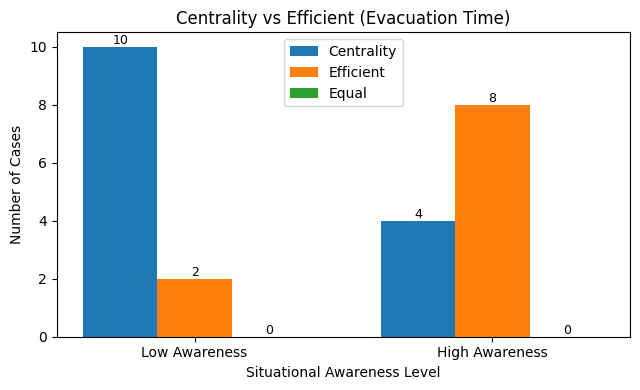

In [32]:
time_df = pd.DataFrame(
    {
        "Centrality": [
            trend_time_summary.loc["Centrality better", "low awareness"],
            trend_time_summary.loc["Centrality better", "high awareness"],
        ],
        "Efficient": [
            trend_time_summary.loc["Efficient better", "low awareness"],
            trend_time_summary.loc["Efficient better", "high awareness"],
        ],
        "Equal": [
            trend_time_summary.loc["Equal", "low awareness"],
            trend_time_summary.loc["Equal", "high awareness"],
        ],
    },
    index=["Low Awareness", "High Awareness"]
)

display(time_df)

plot_centrality_vs_efficient_three_way(
    time_df,
    title="Centrality vs Efficient (Evacuation Time)",
    outname="centrality_vs_efficient_time_3way"
)



## 8) Case-wise ranking table (which strategy is best per case)
This gives you "best strategy per case" and lets you see if one dominates.


In [33]:
# Create a strategy-wise pivot for avg_time
pivot_strategy = df.pivot_table(
    index="case_name",
    columns="strategy",
    values="avg_time",
    aggfunc="mean"
)

# Rank strategies per case (1 = best/lowest time)
ranked = pivot_strategy.rank(axis=1, method="min", ascending=True)

# Identify best strategy label per case
best_strategy = pivot_strategy.idxmin(axis=1)
best_time = pivot_strategy.min(axis=1)

ranking_table = pivot_strategy.copy()
ranking_table["best_strategy"] = best_strategy
ranking_table["best_avg_time"] = best_time

display(ranking_table.sort_values("best_avg_time").head(20))

strategy,high awareness + centrality,high awareness + efficient,low awareness + centrality,low awareness + efficient,best_strategy,best_avg_time
case_name,,,,,,
cruise_ship_case_4,75.7298,67.6478,77.6846,79.8076,high awareness + efficient,67.6478
cruise_ship_case_5,104.5140,90.3660,104.5140,90.3660,high awareness + efficient,90.3660
cruise_ship_case_6,104.5140,90.3660,104.5140,90.3660,high awareness + efficient,90.3660
cruise_ship_case_1,94.9508,92.0932,93.7526,98.7760,high awareness + efficient,92.0932
cruise_ship_case_9,100.0860,100.7100,98.9520,108.1740,low awareness + centrality,98.9520
cruise_ship_case_2,102.6644,99.8724,117.5376,118.6588,high awareness + efficient,99.8724
cruise_ship_case_3,102.8448,100.5210,104.2618,111.2660,high awareness + efficient,100.5210
cruise_ship_case_10,107.4780,104.9220,127.1940,158.1840,high awareness + efficient,104.9220
cruise_ship_case_7,107.9400,111.7740,124.4160,134.1960,high awareness + centrality,107.9400


## 9) Summary of best-strategy frequency
"How many cases does each strategy win?"


In [34]:
best_strategy_counts = best_strategy.value_counts().rename_axis("strategy").reset_index(name="wins")
display(best_strategy_counts)

,strategy,wins
0,high awareness + efficient,8
1,high awareness + centrality,3
2,low awareness + centrality,1


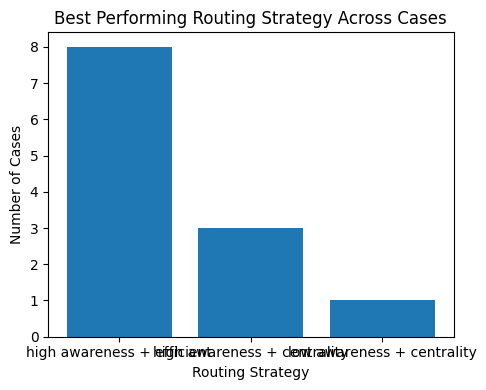

In [35]:
plot_value_counts(
    best_strategy,
    title="Best Performing Routing Strategy Across Cases",
    xlabel="Routing Strategy",
    ylabel="Number of Cases",
    outname="best_strategy_frequency"
)


## 10) Compare by another KPI (mean remaining path risk)
Same structure, but using `mean_remaining_path_risk` (lower is better).


In [36]:
pivot_risk = df.pivot_table(
    index="case_name",
    columns=["awareness", "algorithm"],
    values="mean_remaining_path_risk",   # o "cumulative_risk_exposure"
    aggfunc="mean"
)

display(pivot_risk.head())
print("Pivot columns:", pivot_risk.columns.tolist())

low_c = pivot_risk[("low", "centrality")]
low_e = pivot_risk[("low", "efficient")]

low_c_better = low_c < low_e
low_e_better = low_c > low_e
low_equal    = low_c == low_e

# HIGH awareness
high_c = pivot_risk[("high", "centrality")]
high_e = pivot_risk[("high", "efficient")]

high_c_better = high_c < high_e
high_e_better = high_c > high_e
high_equal    = high_c == high_e


awareness                 high                  low          
algorithm           centrality efficient centrality efficient
case_name                                                    
cruise_ship_case_1    0.000628  0.000577   0.004011  0.006775
cruise_ship_case_10   0.002677  0.008233   0.015377  0.067438
cruise_ship_case_2    0.000684  0.000131   0.019219  0.016634
cruise_ship_case_3    0.001148  0.001168   0.005781  0.011325
cruise_ship_case_4    0.000245  0.000011   0.001940  0.005018

Pivot columns: [('high', 'centrality'), ('high', 'efficient'), ('low', 'centrality'), ('low', 'efficient')]


In [37]:
trend_risk_summary = pd.DataFrame(
    {
        "low awareness": [
            int(low_c_better.sum()),
            int(low_e_better.sum()),
            int(low_equal.sum()),
        ],
        "high awareness": [
            int(high_c_better.sum()),
            int(high_e_better.sum()),
            int(high_equal.sum()),
        ],
    },
    index=["Centrality better", "Efficient better", "Equal"],
)


,Centrality,Efficient,Equal
Low Awareness,11,1,0
High Awareness,5,6,1


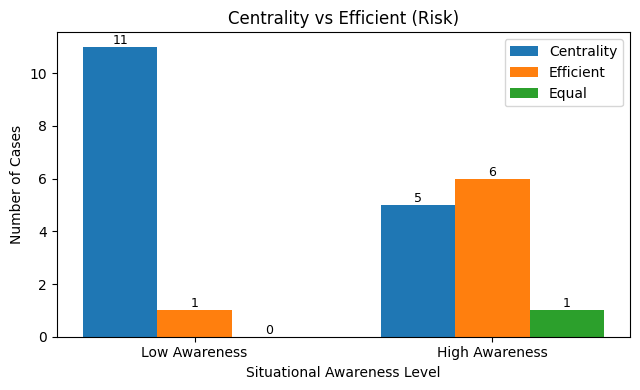

In [38]:
risk_df = pd.DataFrame(
    {
        "Centrality": [
            trend_risk_summary.loc["Centrality better", "low awareness"],
            trend_risk_summary.loc["Centrality better", "high awareness"],
        ],
        "Efficient": [
            trend_risk_summary.loc["Efficient better", "low awareness"],
            trend_risk_summary.loc["Efficient better", "high awareness"],
        ],
        "Equal": [
            trend_risk_summary.loc["Equal", "low awareness"],
            trend_risk_summary.loc["Equal", "high awareness"],
        ],
    },
    index=["Low Awareness", "High Awareness"]
)

display(risk_df)

plot_centrality_vs_efficient_three_way(
    risk_df,
    title="Centrality vs Efficient (Risk)",
    outname="centrality_vs_efficient_risk_3way"
)


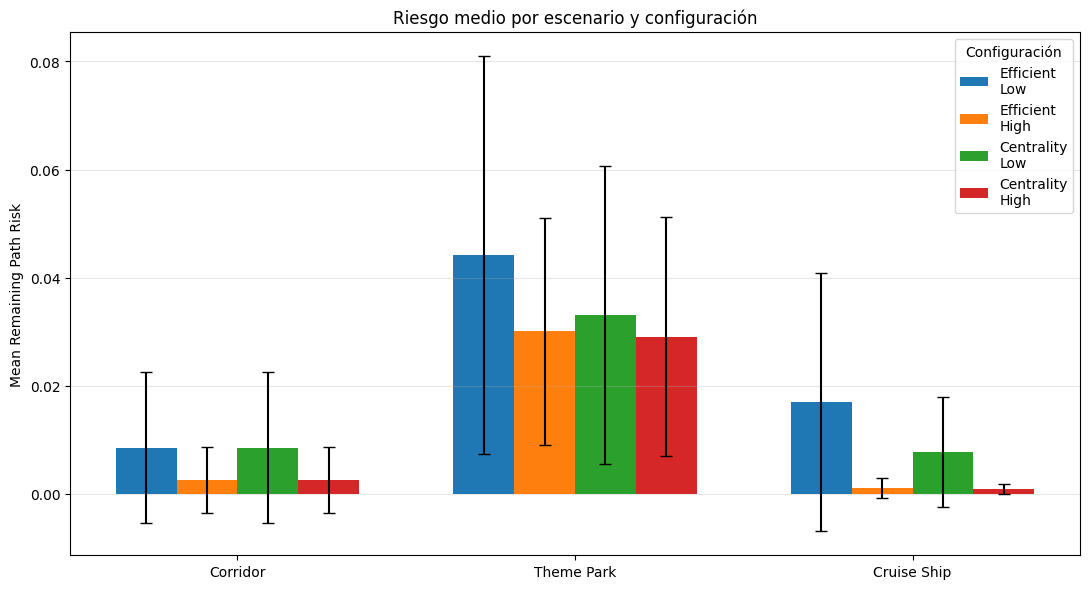

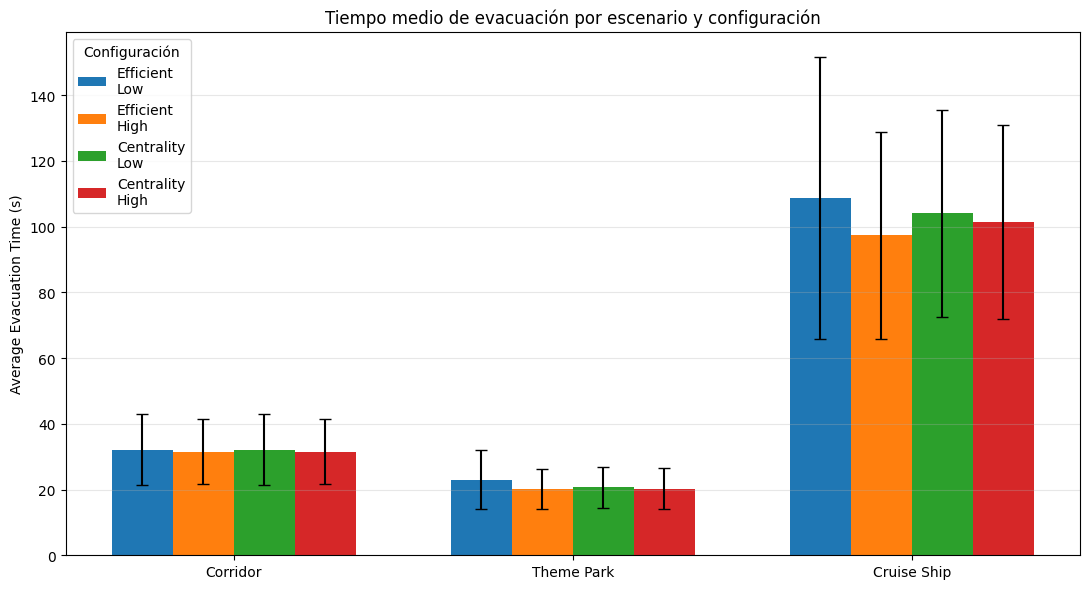

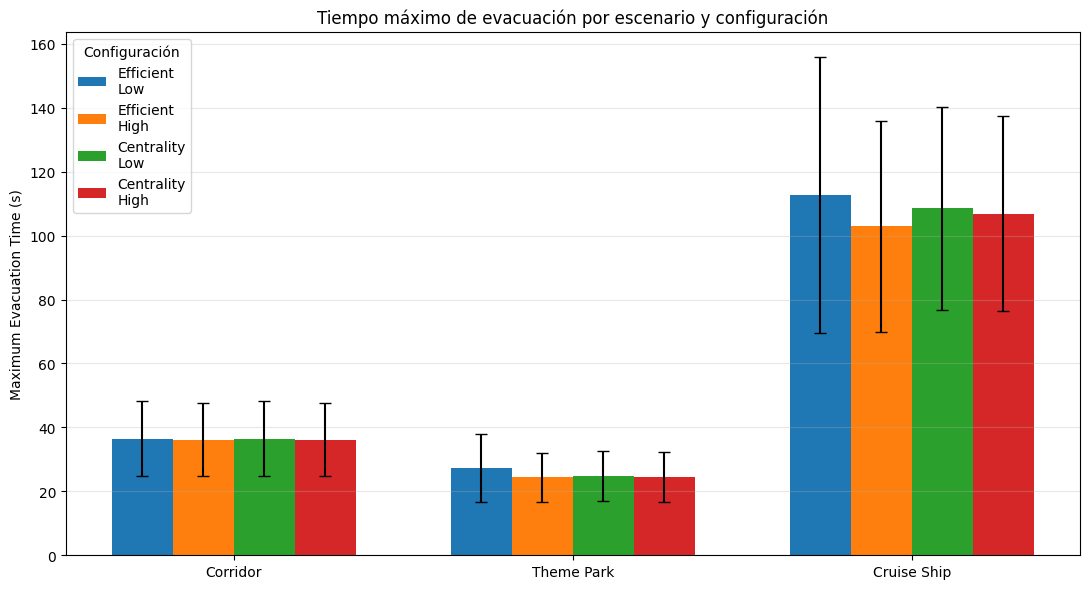


Resumen agregado:

   scenario  algorithm awareness  mean_risk  std_risk  mean_avg_time  std_avg_time  mean_max_time  std_max_time  mean_path_length  std_path_length           config
   Corridor Centrality      High   0.002532  0.006118      31.501754      9.888423      36.155000     11.364719          6.820392         2.535065 Centrality\nHigh
   Corridor Centrality       Low   0.008491  0.014018      32.137108     10.700413      36.430000     11.746776          6.736090         2.511487  Centrality\nLow
   Corridor  Efficient      High   0.002532  0.006118      31.501754      9.888423      36.155000     11.364719          6.820392         2.535065  Efficient\nHigh
   Corridor  Efficient       Low   0.008491  0.014018      32.137108     10.700413      36.430000     11.746776          6.736090         2.511487   Efficient\nLow
Cruise Ship Centrality      High   0.000847  0.000966     101.461875     29.454931     106.888125     30.561727         50.528361        19.842212 Centrality\nH

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# =========================
# 1. Cargar los 3 CSV
# =========================
files = {
    "Corridor": "corridor_experiment_metrics.csv",
    "Theme Park": "Theme Park_experiment_metrics.csv",
    "Cruise Ship": "Cruise_Ship_experiment_metrics.csv",
}

dfs = []
for scenario, file in files.items():
    df = pd.read_csv(f"../results/CSV/{file}")
    df["scenario"] = scenario
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# =========================
# 2. Limpiar columnas
# =========================
# Nos quedamos solo con las columnas que interesan
cols_needed = [
    "scenario",
    "algorithm",
    "awareness",
    "mean_remaining_path_risk",
    "avg_time",
    "max_time",
    "remaining_path_risk_var",
    "avg_path_length",
]
data = data[cols_needed].copy()

# Normalizar textos por si hubiera diferencias
data["algorithm"] = data["algorithm"].str.strip().str.title()
data["awareness"] = data["awareness"].str.strip().str.title()

# Orden deseado
scenario_order = ["Corridor", "Theme Park", "Cruise Ship"]
config_order = [
    ("Efficient", "Low"),
    ("Efficient", "High"),
    ("Centrality", "Low"),
    ("Centrality", "High"),
]

# Etiqueta combinada para los gráficos
data["config"] = data.apply(
    lambda row: f"{row['algorithm']}\n{row['awareness']}",
    axis=1
)

config_labels = [
    "Efficient\nLow",
    "Efficient\nHigh",
    "Centrality\nLow",
    "Centrality\nHigh",
]

# =========================
# 3. Agregar medias y desviaciones
# =========================
summary = (
    data.groupby(["scenario", "algorithm", "awareness"], as_index=False)
    .agg(
        mean_risk=("mean_remaining_path_risk", "mean"),
        std_risk=("mean_remaining_path_risk", "std"),
        mean_avg_time=("avg_time", "mean"),
        std_avg_time=("avg_time", "std"),
        mean_max_time=("max_time", "mean"),
        std_max_time=("max_time", "std"),
        mean_path_length=("avg_path_length", "mean"),
        std_path_length=("avg_path_length", "std"),
    )
)

summary["config"] = summary.apply(
    lambda row: f"{row['algorithm']}\n{row['awareness']}",
    axis=1
)

# Rellenar NaN en std si en algún grupo solo hay un valor
for col in ["std_risk", "std_avg_time", "std_max_time", "std_path_length"]:
    summary[col] = summary[col].fillna(0)

# =========================
# 4. Función para gráfico de barras agrupadas
# =========================
def plot_grouped_bars(summary_df, value_col, error_col, ylabel, title, output_file):
    scenarios = scenario_order
    configs = config_labels

    x = np.arange(len(scenarios))
    width = 0.18

    fig, ax = plt.subplots(figsize=(11, 6))

    for i, config in enumerate(configs):
        vals = []
        errs = []

        for scenario in scenarios:
            subset = summary_df[
                (summary_df["scenario"] == scenario) &
                (summary_df["config"] == config)
            ]

            if len(subset) == 1:
                vals.append(subset.iloc[0][value_col])
                errs.append(subset.iloc[0][error_col])
            else:
                vals.append(np.nan)
                errs.append(0)

        ax.bar(
            x + (i - 1.5) * width,
            vals,
            width,
            yerr=errs,
            capsize=4,
            label=config
        )

    ax.set_xticks(x)
    ax.set_xticklabels(scenios := scenarios)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title="Configuración")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 5. Gráfico 1: Riesgo medio
# =========================
plot_grouped_bars(
    summary,
    value_col="mean_risk",
    error_col="std_risk",
    ylabel="Mean Remaining Path Risk",
    title="Riesgo medio por escenario y configuración",
    output_file="grafico_riesgo.png"
)

# =========================
# 6. Gráfico 2: Tiempo medio de evacuación
# =========================
plot_grouped_bars(
    summary,
    value_col="mean_avg_time",
    error_col="std_avg_time",
    ylabel="Average Evacuation Time (s)",
    title="Tiempo medio de evacuación por escenario y configuración",
    output_file="grafico_tiempo_medio.png"
)

# =========================
# 7. Gráfico opcional: Tiempo máximo
# =========================
plot_grouped_bars(
    summary,
    value_col="mean_max_time",
    error_col="std_max_time",
    ylabel="Maximum Evacuation Time (s)",
    title="Tiempo máximo de evacuación por escenario y configuración",
    output_file="grafico_tiempo_maximo.png"
)

# =========================
# 8. Tabla resumen en consola
# =========================
print("\nResumen agregado:\n")
print(summary.sort_values(["scenario", "algorithm", "awareness"]).to_string(index=False))